# Estudio del Algoritmo Softmax en el Problema del Bandido Multibrazo

*Description:* Este cuaderno presenta un estudio detallado del rendimiento del algoritmo **Softmax** (también conocido como *Boltzmann Exploration*) en el problema del bandido de k-brazos (k-armed bandit).

Se comparan diferentes configuraciones del parámetro de temperatura $\tau$ (tau) para analizar el compromiso entre exploración y explotación en tres tipos de distribuciones de recompensa: **Normal**, **Bernoulli** y **Binomial**.

    Authors: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín
    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
    Date: 2026/02/16

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html

## Preparación del entorno

Importamos las librerías necesarias y configuramos el path para incluir los módulos del proyecto.

In [ ]:
import sys
import os
import numpy as np
from typing import List

# Añadir el directorio src al path para importar los módulos
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from algorithms.softmax import Softmax
from arms.armnormal import ArmNormal
from arms.armbernoulli import ArmBernoulli
from arms.armbinomial import ArmBinomial
from arms.bandit import Bandit
from plotting.plotting import plot_average_rewards, plot_optimal_selections, plot_regret

## Configuración del Motor de Experimentación

Definimos una función `run_experiment` que ejecuta múltiples simulaciones para obtener resultados estadísticamente significativos. Se calculan tres métricas principales:
1. **Recompensa Promedio:** Qué tan bien se desempeña el agente en promedio en cada paso.
2. **Selección Óptima (%):** Con qué frecuencia el agente elige el mejor brazo disponible.
3. **Lamento Acumulado (Regret):** La diferencia acumulada entre la recompensa obtenida y la máxima posible.

In [ ]:
def run_experiment(bandit_generator, algorithms: List[Softmax], steps: int, runs: int):

    n_algos = len(algorithms)
    rewards = np.zeros((n_algos, steps))
    regrets = np.zeros((n_algos, steps))
    optimal_selections = np.zeros((n_algos, steps))

    # Fijar semilla para reproducibilidad general del experimento
    np.random.seed(42)

    print(f"Iniciando simulación: {runs} ejecuciones de {steps} pasos...")

    for run in range(runs):
        # Generar un nuevo entorno para cada ejecución para promediar sobre distintos escenarios
        bandit = bandit_generator()
        optimal_arm = bandit.optimal_arm

        for algo in algorithms:
            algo.reset()

        sum_current_run_expected_value = np.zeros(n_algos)

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                # 1. Seleccionar brazo
                chosen_arm = algo.select_arm()

                # 2. Obtener recompensa
                reward = bandit.pull_arm(chosen_arm)

                # 3. Actualizar algoritmo
                algo.update(chosen_arm, reward)

                # 4. Registrar métricas
                rewards[idx, step] += reward

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                # Cálculo del lamento (Regret)
                if step == 0:
                    sum_current_run_expected_value[idx] = bandit.get_expected_value(chosen_arm)
                else:
                    sum_current_run_expected_value[idx] += bandit.get_expected_value(chosen_arm)

                regrets[idx, step] += (step + 1) * bandit.get_expected_value(optimal_arm) - sum_current_run_expected_value[idx]

    # Promediar resultados
    rewards /= runs
    regrets /= runs
    optimal_selections = (optimal_selections / runs) * 100

    return rewards, regrets, optimal_selections

## Experimento 1: Distribución Normal

Utilizaremos un entorno con 10 brazos, donde las recompensas de cada brazo siguen una distribución **Normal** con varianza unitaria ($\sigma=1.0$). Las medias se eligen aleatoriamente en el rango [0, 5].

In [ ]:
# Parámetros del experimento
k = 10
steps = 2000  # Aumentamos a 2000 para observar mejor la convergencia
runs = 500

def normal_bandit_generator():
    return Bandit(arms=ArmNormal.generate_arms(k=k, mu_min=0, mu_max=5))

# Algoritmos a comparar (distintas temperaturas)
algorithms_normal = [
    Softmax(k=k, tau=0.1),
    Softmax(k=k, tau=0.5),
    Softmax(k=k, tau=1.0),
    Softmax(k=k, tau=2.0)
]

# Ejecutar
rewards_n, regrets_n, optimal_n = run_experiment(normal_bandit_generator, algorithms_normal, steps, runs)

Iniciando simulación: 500 ejecuciones de 2000 pasos...


Resultados Distribución Normal:


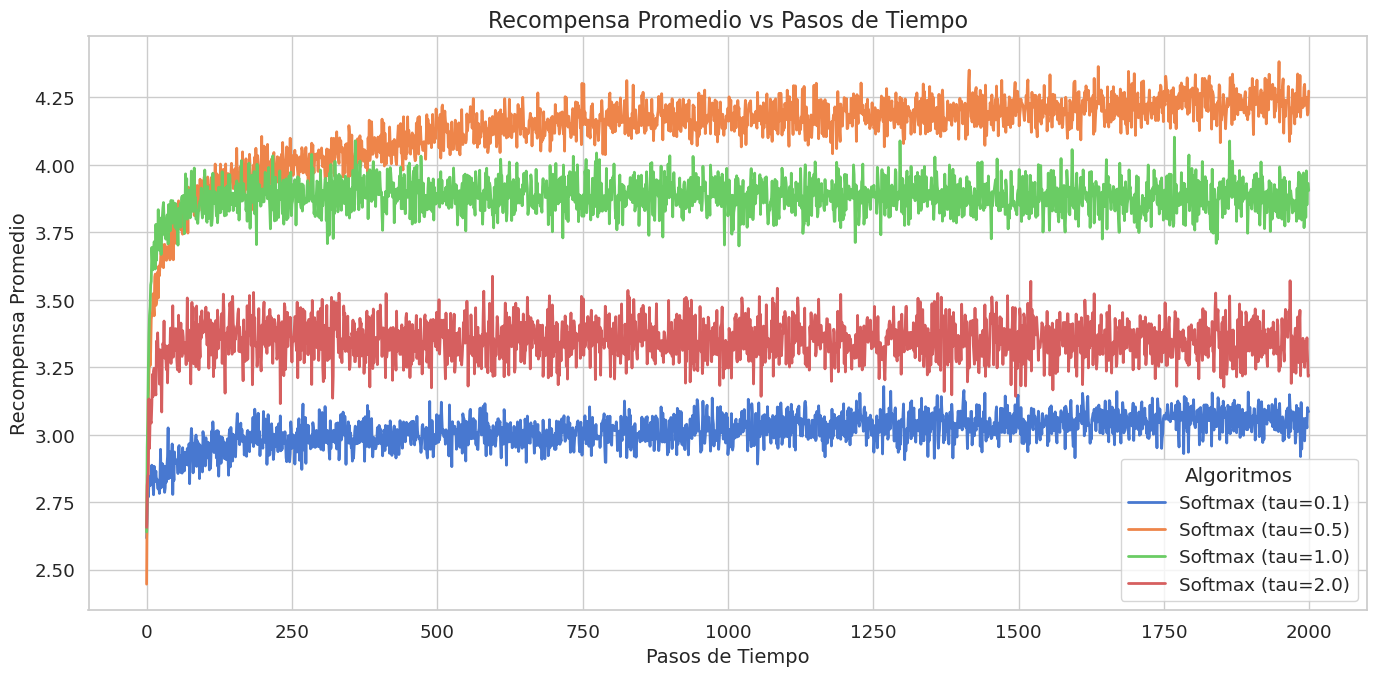

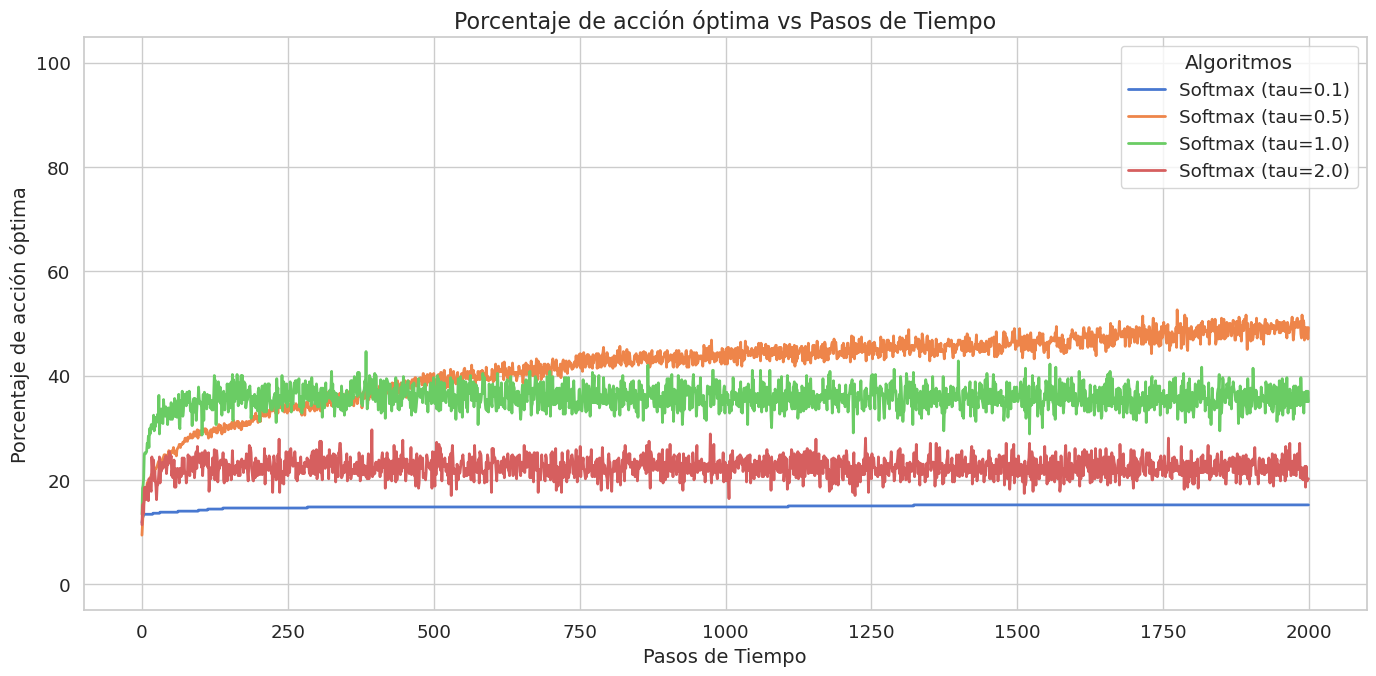

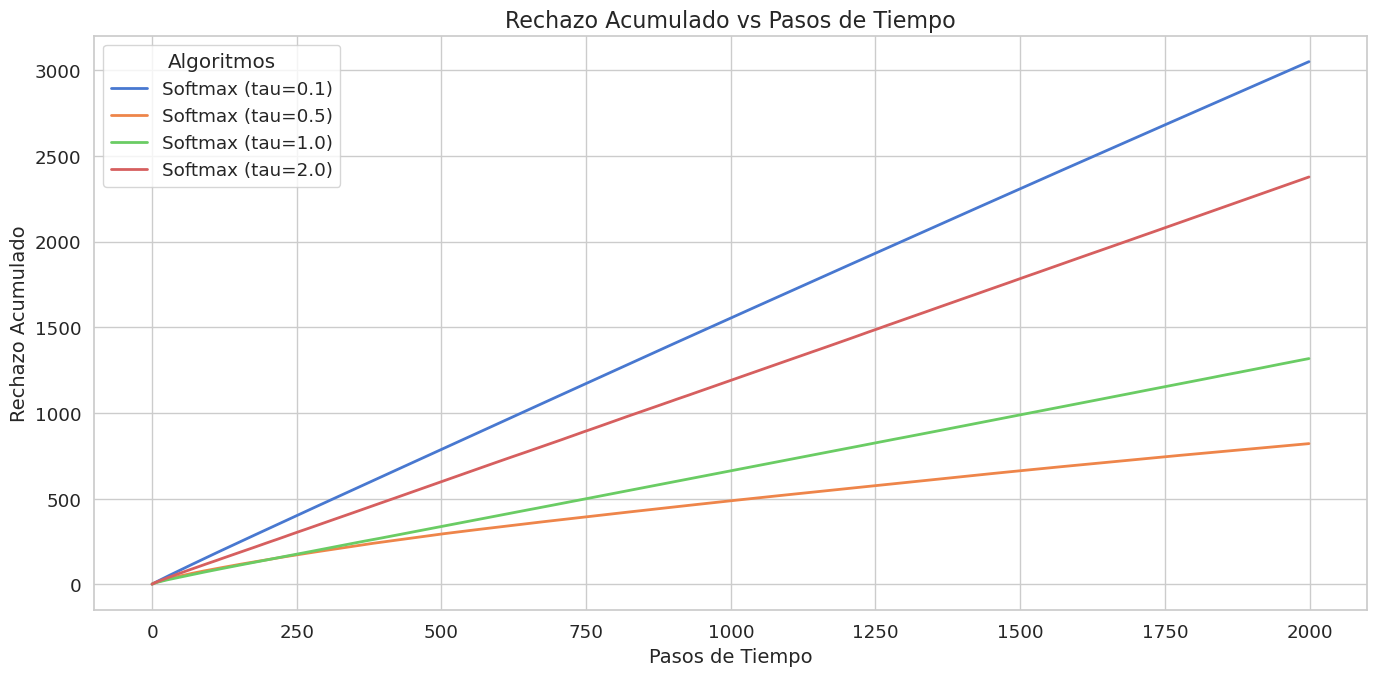

In [ ]:
print("Resultados Distribución Normal:")
plot_average_rewards(steps, rewards_n, algorithms_normal)
plot_optimal_selections(steps, optimal_n, algorithms_normal)
plot_regret(steps, regrets_n, algorithms_normal)

## Experimento 2: Distribución Bernoulli

Utilizaremos un entorno con 10 brazos con distribución **Bernoulli**, donde las recompensas son binarias (0 o 1). Esto es típico en escenarios de Click-Through Rate (CTR).

In [ ]:
def bernoulli_bandit_generator():
    return Bandit(arms=ArmBernoulli.generate_arms(k=k))

# Para Bernoulli, las recompensas son pequeñas (0-1), por lo que temperaturas muy altas
# harán que todas las exponenciales sean similares (e^0 vs e^1/t), llevando a mucha exploración.
# Temperaturas más bajas suelen funcionar mejor aquí.
algorithms_bernoulli = [
    Softmax(k=k, tau=0.01),
    Softmax(k=k, tau=0.1),
    Softmax(k=k, tau=0.2),
    Softmax(k=k, tau=0.5)
]

# Ejecutar
rewards_b, regrets_b, optimal_b = run_experiment(bernoulli_bandit_generator, algorithms_bernoulli, steps, runs)

Iniciando simulación: 500 ejecuciones de 2000 pasos...


Resultados Distribución Bernoulli:


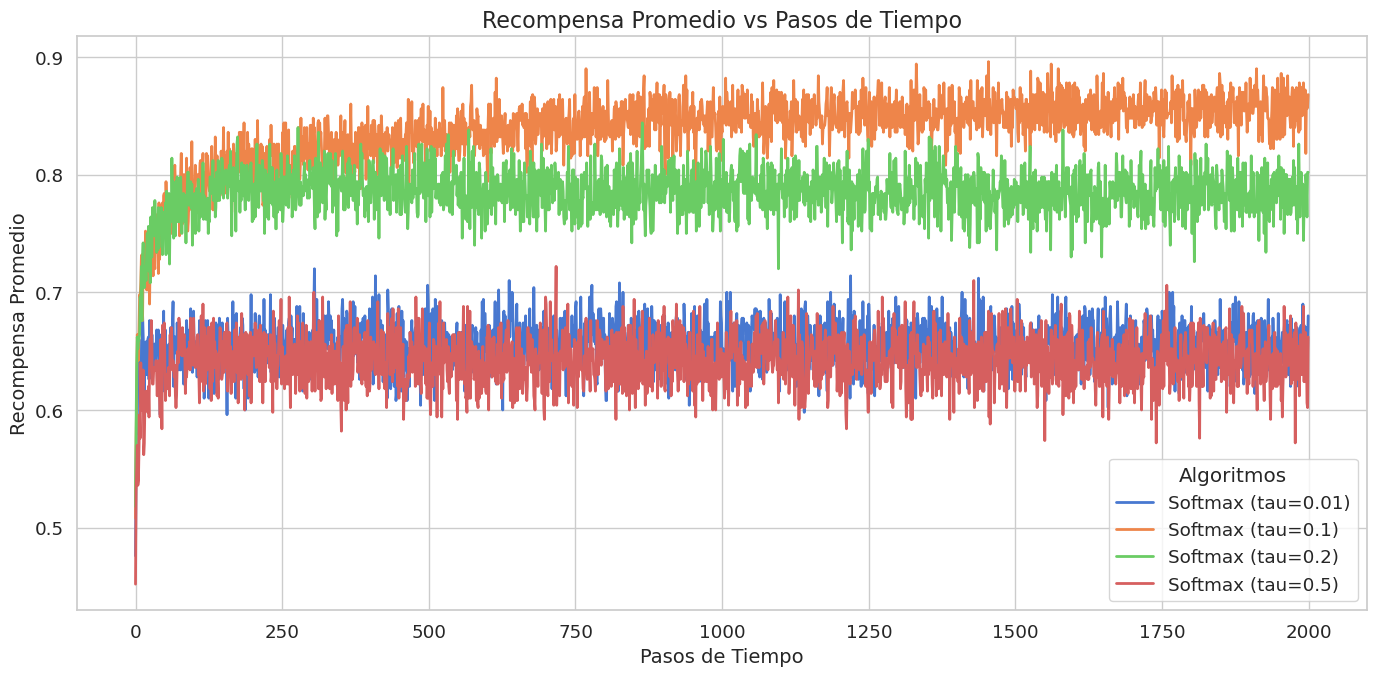

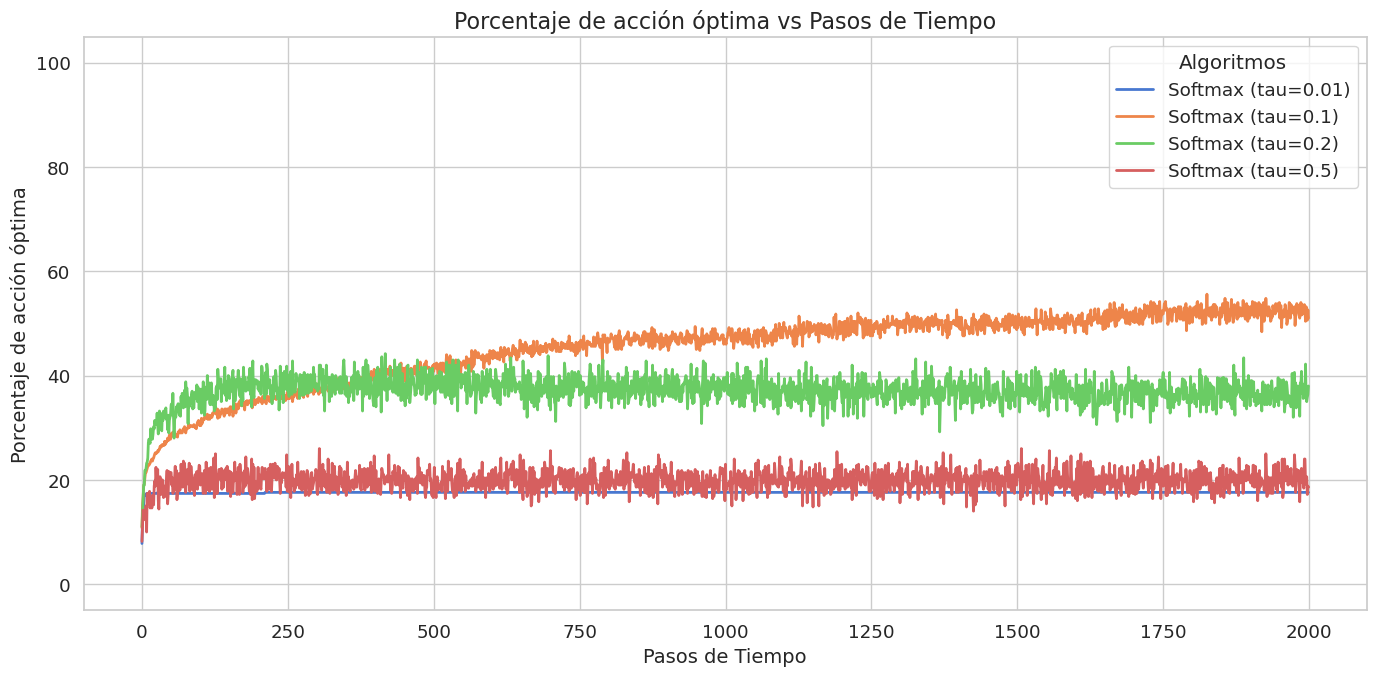

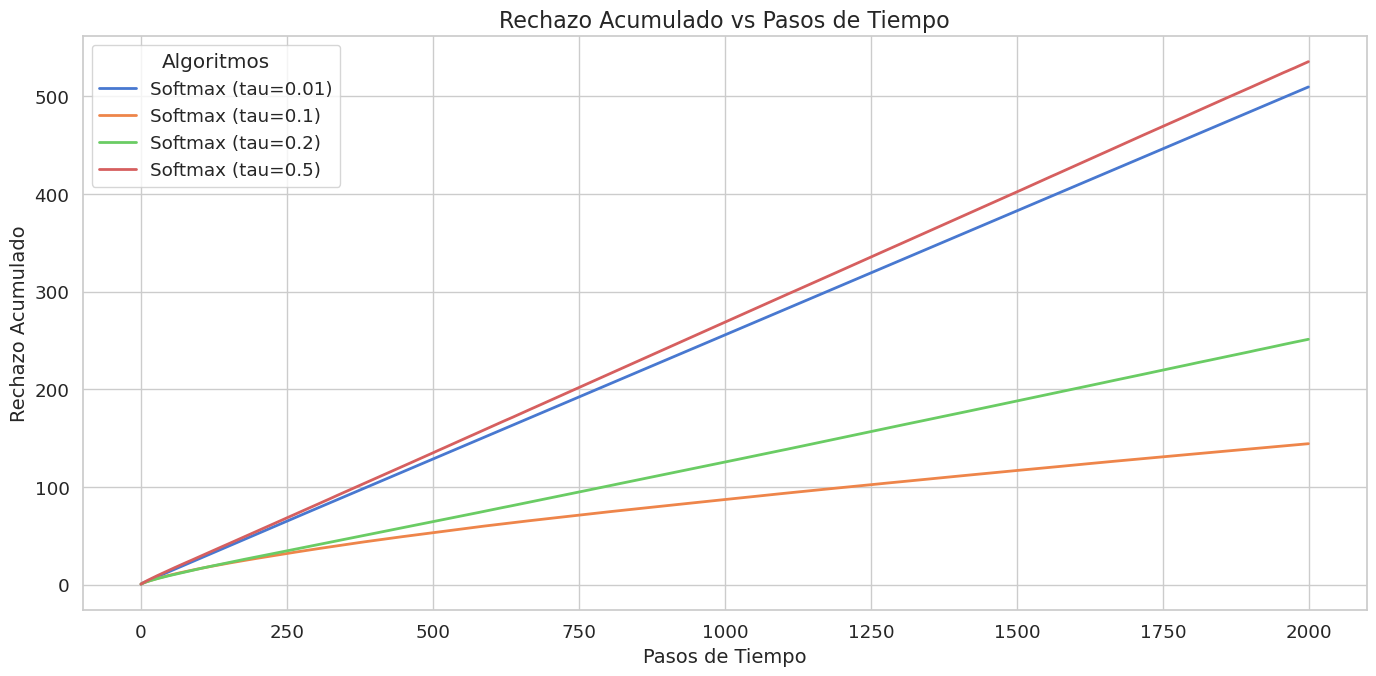

In [ ]:
print("Resultados Distribución Bernoulli:")
plot_average_rewards(steps, rewards_b, algorithms_bernoulli)
plot_optimal_selections(steps, optimal_b, algorithms_bernoulli)
plot_regret(steps, regrets_b, algorithms_bernoulli)

## Experimento 3: Distribución Binomial

Utilizaremos un entorno con 10 brazos con distribución **Binomial** ($n, p$). Las recompensas varían entre 0 y $n$. Esto simula recompensas agregadas (ej. número de conversiones en un lote de usuarios).

In [ ]:
def binomial_bandit_generator():
    # Generamos brazos con n entre 5 y 10 para tener recompensas en escala mayor
    return Bandit(arms=ArmBinomial.generate_arms(k=k, n_min=5, n_max=10))

# Para Binomial, las recompensas son mayores (ej. 0 a 10).
# Valores de Q mayores significan que temperaturas muy bajas harán al algoritmo
# extremadamente determinista (Greedy) muy rápido (overflow de exp).
# Necesitamos temperaturas un poco más altas para mantener la exploración.
algorithms_binomial = [
    Softmax(k=k, tau=0.5),
    Softmax(k=k, tau=1.0),
    Softmax(k=k, tau=2.0),
    Softmax(k=k, tau=5.0)
]

# Ejecutar
rewards_bin, regrets_bin, optimal_bin = run_experiment(binomial_bandit_generator, algorithms_binomial, steps, runs)

Iniciando simulación: 500 ejecuciones de 2000 pasos...


Resultados Distribución Binomial:


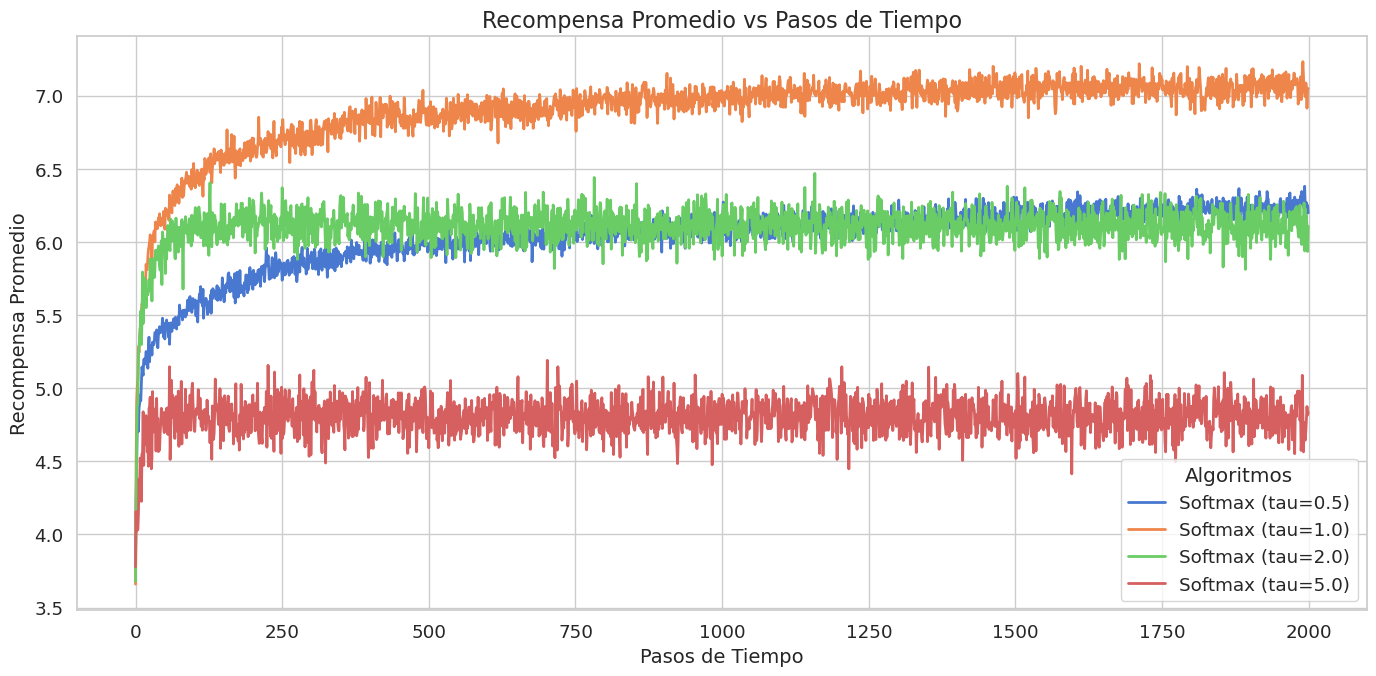

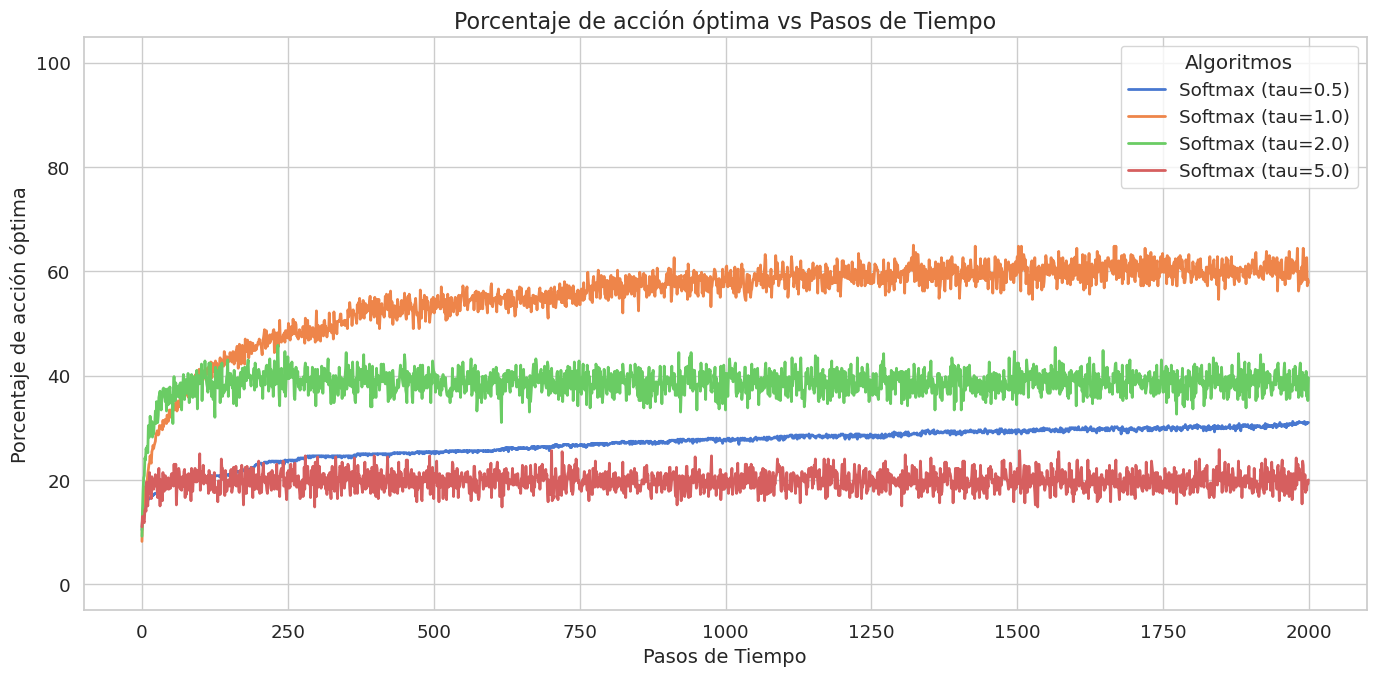

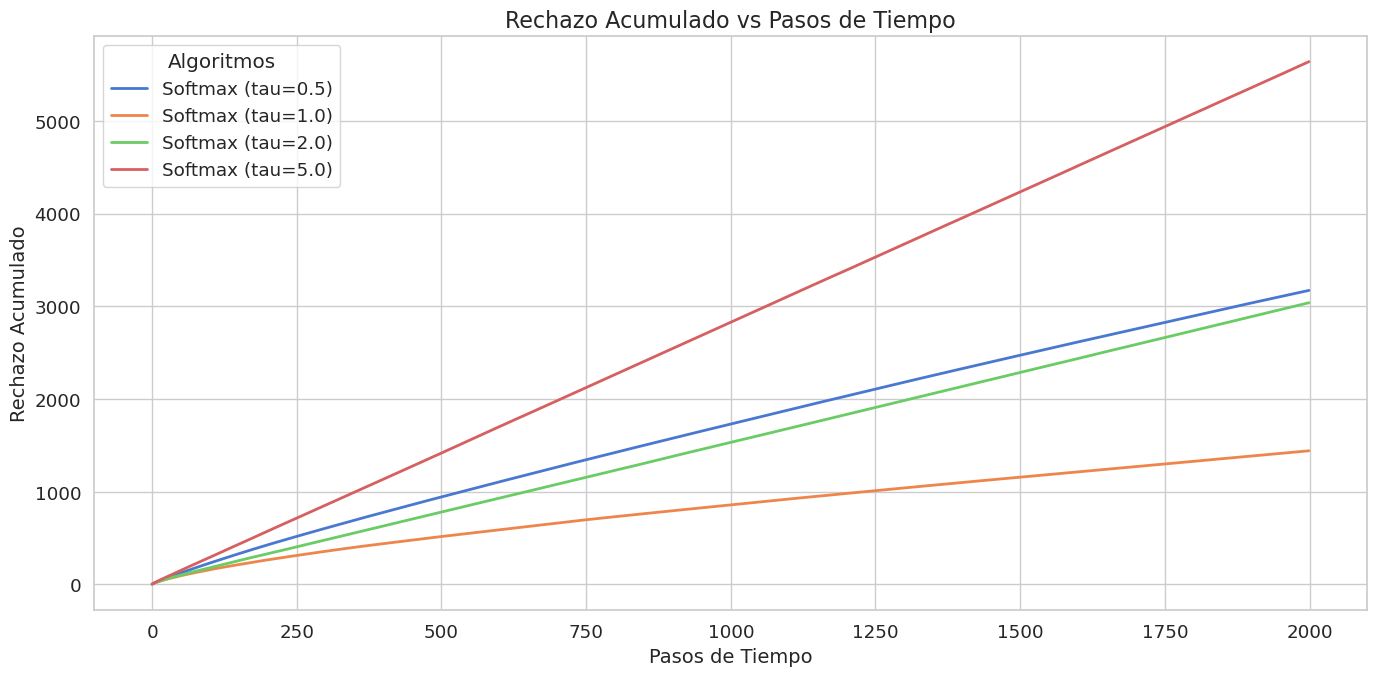

In [ ]:
print("Resultados Distribución Binomial:")
plot_average_rewards(steps, rewards_bin, algorithms_binomial)
plot_optimal_selections(steps, optimal_bin, algorithms_binomial)
plot_regret(steps, regrets_bin, algorithms_binomial)

## Conclusiones Generales

El algoritmo **Softmax** demuestra ser sensible a la escala de las recompensas, ya que el parámetro de temperatura $\tau$ regula directamente la forma de la distribución de probabilidad de selección.

1.  **Sensibilidad a la Escala:**
    -   En entornos **Bernoulli** (recompensas 0-1), se requieren temperaturas bajas ($\tau \approx 0.1$) para explotar eficazmente. Temperaturas altas ($\tau > 0.5$) llevan a una exploración casi uniforme, degradando el rendimiento.
    -   En entornos **Binomiales** (recompensas mayores, e.g., 0-10), se requieren temperaturas más altas ($\tau \approx 1.0 - 2.0$). Una temperatura muy baja haría que el algoritmo converja instantáneamente al primer brazo que dé una recompensa alta, comportándose como un Greedy puro y fallando en explorar lo suficiente.

2.  **Trade-off Exploración/Explotación:**
    -   Las temperaturas intermedias ajustadas a la escala del problema suelen ofrecer el mejor balance. Permiten distinguir claramente entre brazos buenos y malos (alta probabilidad para los buenos) pero mantienen una probabilidad no nula de explorar otros brazos si las estimaciones cambian.
    -   Softmax tiene la ventaja sobre $\epsilon$-greedy de que explora "intigentemente": explora más los brazos que parecen prometedores (segundos mejores) y menos los que son claramente malos, en lugar de elegir totalmente al azar cuando explora.